# Introduction to Potentials

galpy provides a large library of gravitational potentials. This notebook covers how to
initialize potentials, evaluate them, combine them, and compute useful dynamical quantities.

In [1]:
%matplotlib inline
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import (
    MiyamotoNagaiPotential,
    NFWPotential,
    HernquistPotential,
    LogarithmicHaloPotential,
    MWPotential2014,
)
from galpy.util import conversion

## Initializing a potential

Let's start by creating a Miyamoto-Nagai disk potential. In galpy's natural units,
velocities are normalized to the circular velocity at the Sun, and distances to the
Sun's Galactocentric radius.

In [2]:
mp = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=1.0)
mp

MiyamotoNagaiPotential with internal parameters: amp=1.4632953564490085, a=0.5, b=0.0375 and physical outputs off

## Evaluating potential values and forces

Evaluate the potential at (R, z) = (1, 0), i.e., the solar position in natural units:

In [3]:
# Potential value at (R, z) = (1, 0)
print("Phi(R=1, z=0) =", mp(1.0, 0.0))

Phi(R=1, z=0) = -1.2889062500000001


In [4]:
mp(1.0, 0.0)

np.float64(-1.2889062500000001)

**WARNING:** galpy potentials do *not* necessarily approach zero at infinity. To compute, for example, the escape velocity or whether or not an orbit is unbound, you need to take into account the value of the potential at infinity: $v_{\mathrm{esc}}(r) = \sqrt{2[\Phi(\infty)-\Phi(r)]}$. If you want to create a potential that does go to zero at infinity, you can add a `NullPotential` with value equal to minus the original potential evaluated at infinity.

**TIP:** Potentials can be initialized and evaluated with arguments specified as astropy Quantities with units. Use the configuration parameter `astropy-units = True` to get output values as a Quantity. See the subsection on initializing potentials with parameters with units below.

In [5]:
# Radial and vertical forces
print("F_R(R=1, z=0) =", mp.Rforce(1.0, 0.0))
print("F_z(R=1, z=0.1) =", mp.zforce(1.0, 0.1))

F_R(R=1, z=0) = -1.0
F_z(R=1, z=0.1) = -0.5194918992748312


## The functional interface

galpy also provides module-level functions that work on single potentials or lists of potentials:

In [6]:
print("evaluatePotentials:", potential.evaluatePotentials(mp, 1.0, 0.0))
print("evaluateRforces:", potential.evaluateRforces(mp, 1.0, 0.0))
print("evaluatezforces:", potential.evaluatezforces(mp, 1.0, 0.1))

evaluatePotentials: -1.2889062500000001
evaluateRforces: -1.0
evaluatezforces: -0.5194918992748312


## Combining potentials

Potentials can be combined using the `+` operator. `MWPotential2014` is a built-in
composite potential with three components:

In [7]:
# MWPotential2014 is a composite potential
print(type(MWPotential2014))
print("Number of components:", len(MWPotential2014))
for p in MWPotential2014:
    print(" ", type(p).__name__)

<class 'galpy.potential.CompositePotential.CompositePotential'>
Number of components: 3
  PowerSphericalPotentialwCutoff
  MiyamotoNagaiPotential
  NFWPotential


In [8]:
# You can also combine potentials yourself
my_pot = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=0.6) + NFWPotential(
    a=4.5, normalize=0.35
)
print("Phi(1,0) =", potential.evaluatePotentials(my_pot, 1.0, 0.0))

Phi(1,0) = -4.498828040219292


## Converting to physical units

To convert from natural units to physical units, use `galpy.util.conversion`:

In [9]:
ro, vo = 8.0, 220.0  # kpc, km/s
# Force in natural units
F_R_nat = potential.evaluateRforces(MWPotential2014, 1.0, 0.0)
# Convert to physical (km/s^2/kpc)
F_R_phys = F_R_nat * conversion.force_in_kmsMyr(vo, ro) / 1000.0  # to km/s^2/kpc
print(
    f"F_R at solar position: {F_R_nat:.4f} (natural), {F_R_phys:.6f} km/s^2/kpc (physical)"
)

F_R at solar position: -1.0000 (natural), -0.006187 km/s^2/kpc (physical)


## Densities

You can evaluate the density directly or via the Poisson equation:

In [10]:
# Direct density evaluation
print("Density (direct):", mp.dens(1.0, 0.0))
# Via the Poisson equation
print("Density (Poisson):", mp.dens(1.0, 0.0, forcepoisson=True))

Density (direct): 1.1145444383277576
Density (Poisson): 1.1145444383277574


In [11]:
# Functional interface for lists of potentials
print(
    "MWPotential2014 density at (1,0):",
    potential.evaluateDensities(MWPotential2014, 1.0, 0.0),
)

MWPotential2014 density at (1,0): 0.5750860312226487


## DoubleExponentialDiskPotential density

Another example: an exponential disk potential, where we can compare the
analytical density to that computed via the Poisson equation.

/home/bovy/Repos/galpy/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/home/bovy/Repos/galpy/galpy/potential/DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

/home/bovy/Repos/galpy/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

Relative difference: 1.5308327107952697e-14


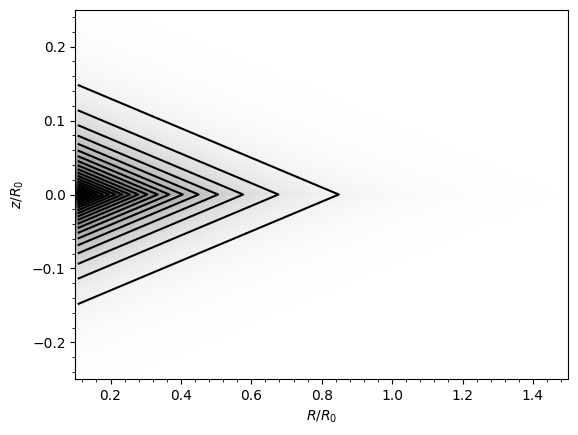

In [12]:
from galpy.potential import DoubleExponentialDiskPotential

dp = DoubleExponentialDiskPotential(hr=1.0 / 4.0, hz=1.0 / 20.0, normalize=1.0)
# The Poisson-equation density requires numerical integration, so the agreement
# is slightly less good than for Miyamoto-Nagai, but still better than a percent:
print(
    "Relative difference:",
    (dp.dens(1.0, 0.0, forcepoisson=True) - dp.dens(1.0, 0.0)) / dp.dens(1.0, 0.0),
)
dp.plotDensity(rmin=0.1, zmax=0.25, zmin=-0.25, nrs=101, nzs=101)

## Flattening

We can evaluate the flattening of the potential as $\sqrt{|z\,F_R / R\,F_Z|}$:

In [13]:
print("Flattening of Miyamoto-Nagai at (1, 0.125):", mp.flattening(1.0, 0.125))
print(
    "Flattening of MWPotential2014 at (1, 0.125):",
    MWPotential2014.flattening(1.0, 0.125),
)

Flattening of Miyamoto-Nagai at (1, 0.125): 0.4549542914935209
Flattening of MWPotential2014 at (1, 0.125): 0.6123167530565863


## Plotting potentials

galpy potentials have built-in plotting methods:

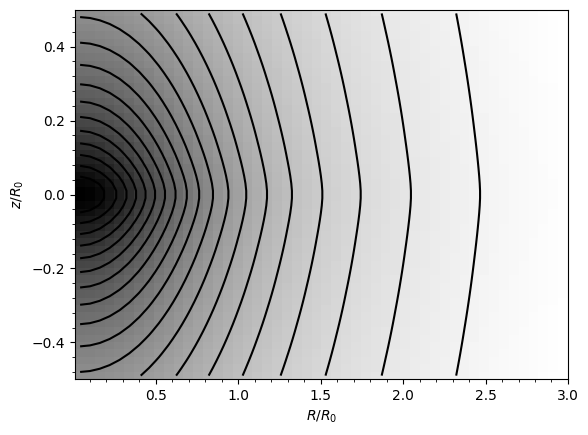

In [14]:
# Plot the potential in the (R, z) plane
mp.plot(rmin=0.01, rmax=3.0, zmin=-0.5, zmax=0.5, nrs=50, nzs=50)

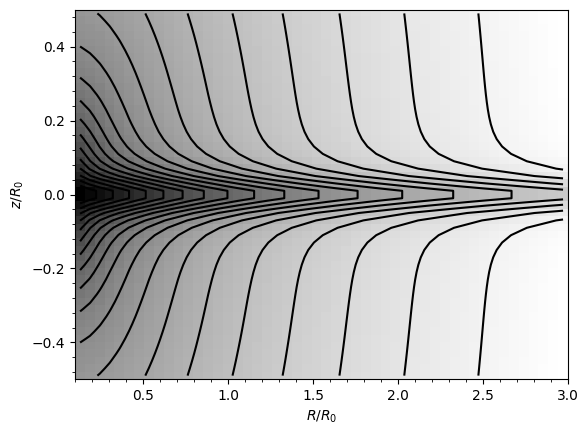

In [15]:
# Plot the density
potential.plotDensities(
    MWPotential2014, rmin=0.1, rmax=3.0, zmin=-0.5, zmax=0.5, nrs=50, nzs=50, log=True
)

## Circular-orbit quantities

galpy can compute circular velocity, epicycle frequency, vertical frequency,
and angular frequency:

In [16]:
print("v_circ(R=1):", MWPotential2014.vcirc(1.0))
print("Omega_c(R=1):", MWPotential2014.omegac(1.0))
print("Epicycle freq(R=1):", MWPotential2014.epifreq(1.0))
print("Vertical freq(R=1):", MWPotential2014.verticalfreq(1.0))

v_circ(R=1): 1.0
Omega_c(R=1): 1.0
Epicycle freq(R=1): 1.340959647011537
Vertical freq(R=1): 2.7255405754769875


(0.0, 1.5)

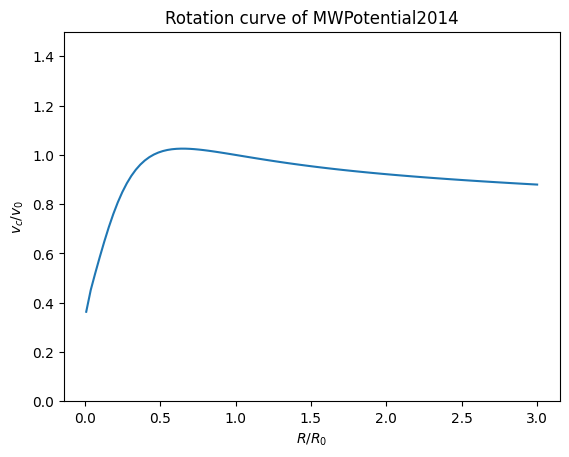

In [17]:
# Plot the rotation curve
Rs = numpy.linspace(0.01, 3.0, 101)
plt.plot(Rs, [MWPotential2014.vcirc(R) for R in Rs])
plt.xlabel(r"$R / R_0$")
plt.ylabel(r"$v_c / v_0$")
plt.title("Rotation curve of MWPotential2014")
plt.ylim(0, 1.5)

## Spiral density wave diagram: $\Omega - n\kappa/m$

The diagram of $\Omega - n\kappa/m$ is important for understanding kinematic
spiral density waves. It shows the locations of various resonances.

Text(0.5, 1.0, '$\\Omega - n\\kappa/m$ diagram for MWPotential2014')

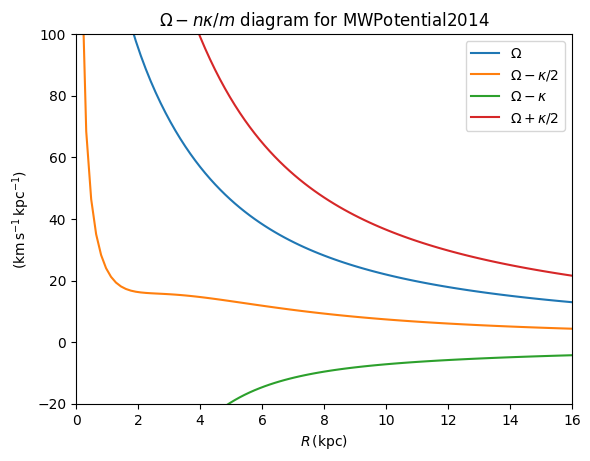

In [18]:
def OmegaMinusKappa(pot, Rs, n, m, ro=8.0, vo=220.0):
    """Compute Omega - n*kappa/m. Rs in units of ro."""
    return pot.omegac(Rs / ro, ro=ro, vo=vo) - n / m * pot.epifreq(
        Rs / ro, ro=ro, vo=vo
    )


Rs = numpy.linspace(0.01, 16.0, 101)  # kpc
plt.plot(Rs, OmegaMinusKappa(MWPotential2014, Rs, 0, 1), label=r"$\Omega$")
plt.plot(Rs, OmegaMinusKappa(MWPotential2014, Rs, 1, 2), label=r"$\Omega - \kappa/2$")
plt.plot(Rs, OmegaMinusKappa(MWPotential2014, Rs, 1, 1), label=r"$\Omega - \kappa$")
plt.plot(Rs, OmegaMinusKappa(MWPotential2014, Rs, 1, -2), label=r"$\Omega + \kappa/2$")
plt.xlim(0.0, 16.0)
plt.ylim(-20.0, 100.0)
plt.xlabel(r"$R\,(\mathrm{kpc})$")
plt.ylabel(r"$(\mathrm{km\,s}^{-1}\,\mathrm{kpc}^{-1})$")
plt.legend(fontsize=10)
plt.title(r"$\Omega - n\kappa/m$ diagram for MWPotential2014")

## Lindblad resonances

Find the radius of the inner and outer Lindblad resonances for a given pattern speed:

In [19]:
# Lindblad resonances for a pattern speed similar to the Milky Way's bar
# Using the Miyamoto-Nagai potential for this example:
print("Corotation:", mp.lindbladR(5.0 / 3.0, m="corotation"))
print("Inner Lindblad resonance (m=2):", mp.lindbladR(5.0 / 3.0, m=2))
print("Outer Lindblad resonance (m=-2):", mp.lindbladR(5.0 / 3.0, m=-2))

Corotation: 0.6027911166042229
Inner Lindblad resonance (m=2): None
Outer Lindblad resonance (m=-2): 0.9906190683480501


The `None` for `m=2` means there is no inner Lindblad resonance for this potential.
The `m=-2` resonance is in the Solar neighborhood (see the section on the
Hercules stream in the galpy documentation).

## Interpolated potentials

For expensive potentials, galpy provides `interpRZPotential` (for axisymmetric potentials)
and `interpSphericalPotential` (for spherical potentials) that pre-compute a grid and
interpolate. `interpSphericalPotential` can be initialized from a function giving the
radial force or from an existing spherical potential. See the API documentation
for full details.

In [20]:
from galpy.potential import interpRZPotential

# Create an interpolated version of MWPotential2014
ip = interpRZPotential(
    RZPot=MWPotential2014,
    rgrid=(0.01, 3.0, 51),
    zgrid=(0.0, 0.5, 26),
    interpPot=True,
    interpRforce=True,
    interpzforce=True,
)
# Compare
print("Original:", potential.evaluatePotentials(MWPotential2014, 1.0, 0.1))
print("Interpolated:", ip(1.0, 0.1))

Original: -1.3531320418152721
Interpolated: -1.3531320418152721


## Initializing with physical units

You can initialize potentials using physical units by setting `ro` and `vo` and
passing physical parameters:

In [21]:
from astropy import units as u

# NFW halo with a mass and scale radius in physical units
nfw = NFWPotential(mvir=1.0, conc=15.0, ro=8.0, vo=220.0)
# Evaluate at 8 kpc -- returns in physical units (km^2/s^2) when using quantities
print("Phi(8 kpc, 0 kpc):", nfw(8.0 * u.kpc, 0.0 * u.kpc))

Phi(8 kpc, 0 kpc): -96354.67477240822


In [22]:
# Miyamoto-Nagai with physical amplitude
mn_phys = MiyamotoNagaiPotential(
    amp=5e10 * u.Msun, a=3.0 * u.kpc, b=0.28 * u.kpc, ro=8.0, vo=220.0
)
print("v_circ(R=1):", mn_phys.vcirc(1.0))

v_circ(R=1): 145.9185599862874


**Amplitude units vary by potential type.** The `amp=` parameter has different units
for different potentials. For example, for a `LogarithmicHaloPotential` the units are
velocity squared, while for a `MiyamotoNagaiPotential` they are units of mass.
Check each potential's API documentation for the units of `amp=`.

**WARNING:** When combining potentials with different `ro=` and `vo=` values, unexpected
behavior can result. It is best to use the same `ro=` and `vo=` for all potentials
in a combination.